#Heart Disease Prediction

This Project predicts the likelihood of heart disease using machine learning classification algorithms.

The goal is to compare mutiple models and identify the best-performing classifier.

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hashshamabid","key":"b135295876cbe9a5178d92010c8eb7c5"}'}

In [13]:
!pip install catboost
!pip install xgboost
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s eta 0:00:00


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d "johnsmith88/heart-disease-dataset"

Dataset URL: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
License(s): unknown
100% 6.18k/6.18k [00:00<00:00, 20.7MB/s]



In [4]:
!unzip heart-disease-dataset.zip

Archive:  heart-disease-dataset.zip
  inflating: heart.csv               


In [5]:
import pandas as pd
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
print(df.isnull().sum())
print(df["target"].value_counts())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
target
1    526
0    499
Name: count, dtype: int64


In [7]:
X = df.drop("target", axis=1)
y = df["target"]



In [25]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

models = {
    "SVC": SVC(kernel="rbf"),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=400,random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(n_jobs=10),
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=8),
    "XGBClassifier": XGBClassifier(),
    "GaussianNB": GaussianNB(),
    "CatBoostClassifier": CatBoostClassifier(verbose=0),
    "LGBMClassifier": LGBMClassifier()
}

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, average_precision_score

results = []


x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

for name,model in models.items():
  pipe = Pipeline([
      ('scaler', StandardScaler()),
      ('model', model)
  ])

  pipe.fit(x_train,y_train)

  predict = pipe.predict(x_test)

  results.append({
      "model": name,
      "accuracy": accuracy_score(y_test,predict)
  })

  print(f"Model: {name}")
  print(f"Accuracy: {accuracy_score(y_test,predict)}")
  print(f"Classification Report:\n {classification_report(y_test,predict)}")
  print(f"Confusion Matrix:\n {confusion_matrix(y_test,predict)}")


Model: SVC
Accuracy: 0.8878048780487805
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205

Confusion Matrix:
 [[85 17]
 [ 6 97]]
Model: RandomForestClassifier
Accuracy: 0.9853658536585366
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Confusion Matrix:
 [[102   0]
 [  3 100]]
Model: DecisionTreeClassifier
Accuracy: 0.9853658536585366
Classification Report:
               precision    recall  f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [27]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="accuracy", ascending=False)

,model,accuracy
1,RandomForestClassifier,0.985366
8,LGBMClassifier,0.985366
2,DecisionTreeClassifier,0.985366
7,CatBoostClassifier,0.985366
5,XGBClassifier,0.985366
0,SVC,0.887805
4,KNeighborsClassifier,0.839024
6,GaussianNB,0.800000
3,LogisticRegression,0.795122


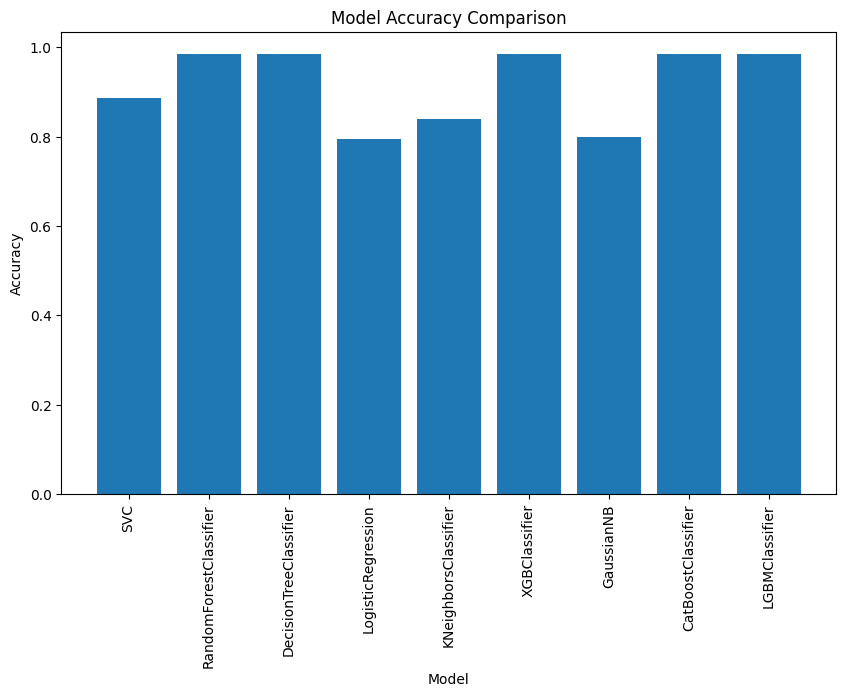

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(results_df["model"], results_df["accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=90)
plt.show()

##Best Model Selection

Random Forest achieved the highest accuracy among all tested models.

In [29]:
best_model = RandomForestClassifier(n_estimators=400)

best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

best_pipe.fit(x_train,y_train)

print(f"Accuracy: {accuracy_score(y_test,best_pipe.predict(x_test))}")
print(f"Classification Report:\n {classification_report(y_test,best_pipe.predict(x_test))}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test,best_pipe.predict(x_test))}")


Accuracy: 0.9853658536585366
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Confusion Matrix:
 [[102   0]
 [  3 100]]


## Model Evaluation and Visualization


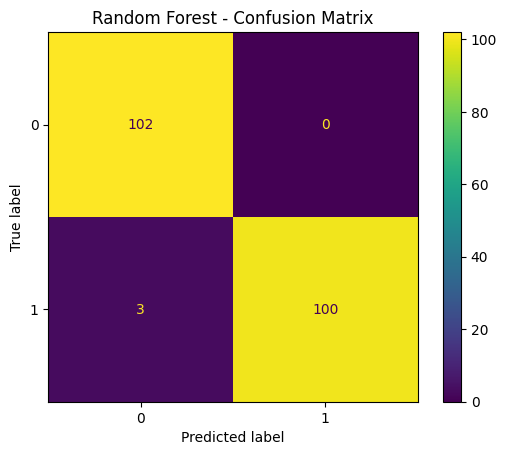

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,best_pipe.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

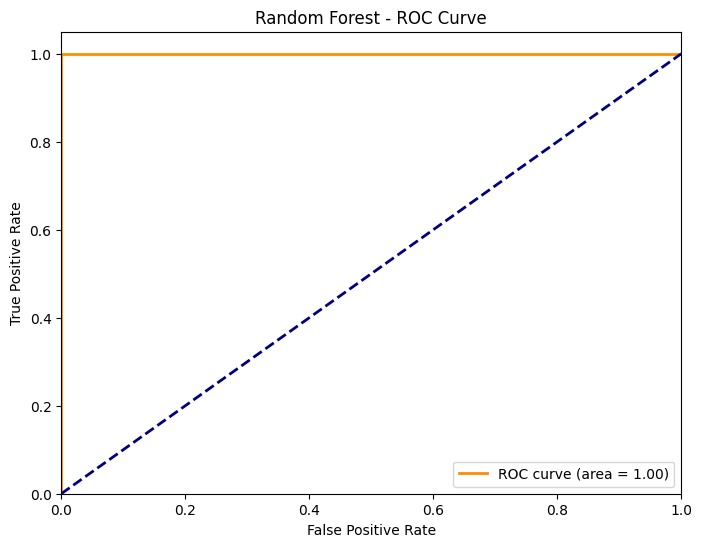

In [32]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = best_pipe.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],color='navy',lw=2,linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest - ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [31]:
import joblib
joblib.dump(best_pipe, "heart_disease_best_model.joblib")

['heart_disease_best_model.joblib']